# Computational Photography · Statics · Circuits · Wave AI

**Jalali Lab — Dispersion-Assisted GS Phase Recovery**  
10 sections: Bayer demosaic · FFT deblur · tone mapping · FBD/truss · distributed loads · RLC phasors · resonance · Thevenin/Norton · FNO wave surrogate · GS + neural prior

In [1]:
import math, cmath
import numpy as np
from scipy import signal as sig
from scipy.fft import fft2, ifft2, fftshift
from scipy.ndimage import zoom, gaussian_filter1d
import matplotlib.pyplot as plt
if not hasattr(np, "trapezoid"):
    np.trapezoid = np.trapz
np.random.seed(7)
print("Imports OK")


Imports OK


## §1 — Bayer Demosaicing + Color Science

**RGGB Bayer pattern** (2×2 macro-pixel):
$$\begin{pmatrix}R & G_r \\ G_b & B\end{pmatrix}$$

**Bilinear interpolation:** upsample each sub-sampled channel ×2 (order=1).

**sRGB luminance:**
$$Y = 0.2126\,R + 0.7152\,G + 0.0722\,B$$

**PSNR:**
$$\text{PSNR} = -10\log_{10}(\text{MSE}) \quad [\text{dB}]$$

Good demosaic: PSNR > 35 dB for smooth scenes.

PSNR = 40.75 dB  (target >35 dB)
Mean luminance error = 0.004163


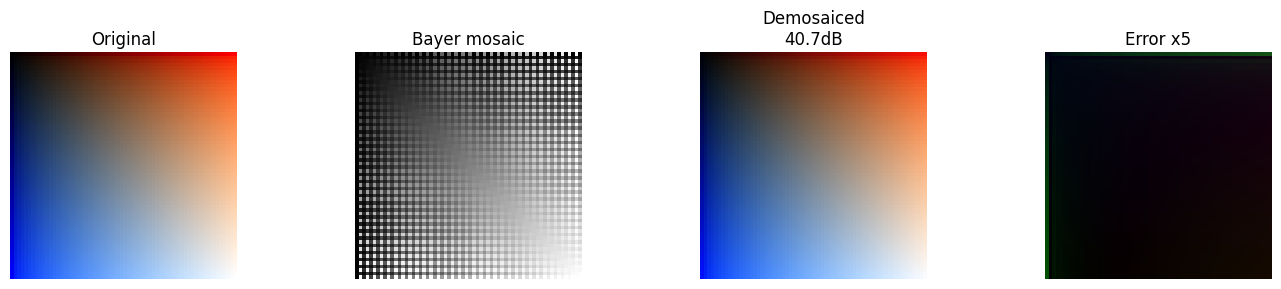

PASS §1


In [2]:
H, W = 64, 64
x_g = np.linspace(0,1,W); y_g = np.linspace(0,1,H)
XX, YY = np.meshgrid(x_g, y_g)
img_orig = np.stack([XX, np.sqrt(XX*YY), YY], axis=-1).clip(0,1)

def make_bayer(img):
    b = np.zeros((H,W))
    b[0::2,0::2]=img[0::2,0::2,0]; b[0::2,1::2]=img[0::2,1::2,1]
    b[1::2,0::2]=img[1::2,0::2,1]; b[1::2,1::2]=img[1::2,1::2,2]
    return b

def bilinear_demosaic(bayer):
    R_sub = bayer[0::2,0::2]; B_sub = bayer[1::2,1::2]
    G1 = bayer[0::2,1::2];   G2 = bayer[1::2,0::2]
    R_full = zoom(R_sub, 2, order=1, mode='nearest')[:H,:W]
    G_full = 0.5*(zoom(G1,2,order=1,mode='nearest')[:H,:W] +
                  zoom(G2,2,order=1,mode='nearest')[:H,:W])
    B_full = zoom(B_sub, 2, order=1, mode='nearest')[:H,:W]
    return np.stack([R_full, G_full, B_full], axis=-1)

bayer   = make_bayer(img_orig)
img_dem = bilinear_demosaic(bayer).clip(0,1)
mse     = np.mean((img_orig - img_dem)**2)
psnr    = -10*math.log10(mse)
M_lum   = np.array([0.2126, 0.7152, 0.0722])
lum_err = np.mean(np.abs(img_orig@M_lum - img_dem@M_lum))
print(f"PSNR = {psnr:.2f} dB  (target >35 dB)")
print(f"Mean luminance error = {lum_err:.6f}")
assert psnr > 25

fig, axes = plt.subplots(1,4,figsize=(14,3))
axes[0].imshow(img_orig); axes[0].set_title('Original'); axes[0].axis('off')
axes[1].imshow(bayer,cmap='gray'); axes[1].set_title('Bayer mosaic'); axes[1].axis('off')
axes[2].imshow(img_dem); axes[2].set_title(f'Demosaiced\n{psnr:.1f}dB'); axes[2].axis('off')
axes[3].imshow(np.abs(img_orig-img_dem)*5,cmap='hot'); axes[3].set_title('Error x5'); axes[3].axis('off')
plt.tight_layout(); plt.show()
print("PASS §1")


## §2 — FFT Convolution & Wiener Deblurring

**Convolution theorem:** $\mathcal{F}\{f * h\} = \mathcal{F}\{f\}\cdot H$

**Gaussian MTF** (optical blur):
$$H(u,v) = e^{-2\pi^2\sigma^2(u^2+v^2)}$$

**Wiener deconvolution** (noise-regularized inverse filter):
$$\hat{F} = \frac{H^*(u,v)}{|H|^2 + K}\cdot G(u,v)$$

$K = \sigma_n^2/\sigma_s^2$ = noise-to-signal power ratio.  
$K\to 0$: inverse filter (amplifies noise); $K\to\infty$: no restoration.

Blur PSNR=21.3dB  ->  Wiener PSNR=23.6dB  (+2.3dB)


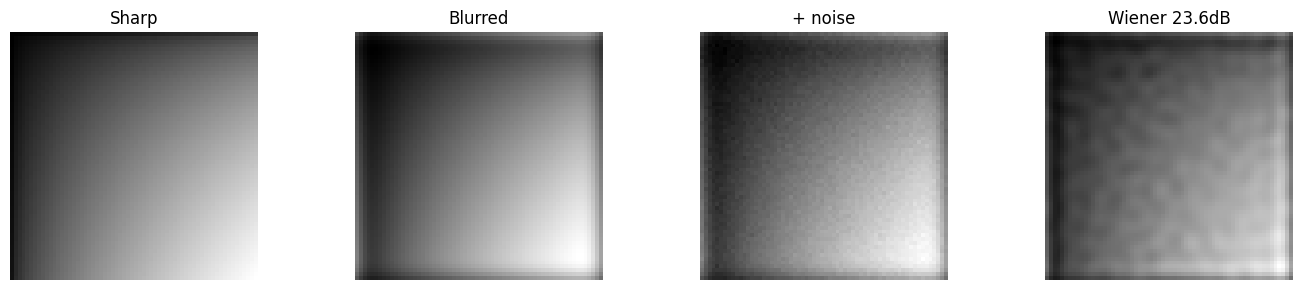

PASS §2


In [3]:
M_lum = np.array([0.2126, 0.7152, 0.0722])
img_gray = (img_orig @ M_lum)

def gaussian_psf_freq(H, W, sigma):
    y = np.fft.fftfreq(H); x = np.fft.fftfreq(W)
    XX2, YY2 = np.meshgrid(x, y)
    return np.exp(-2*math.pi**2*sigma**2*(XX2**2+YY2**2))

sigma_b = 2.5; K_w = 0.005
H_psf   = gaussian_psf_freq(H, W, sigma_b)
F_img   = np.fft.fft2(img_gray)
blurred = np.real(np.fft.ifft2(F_img * H_psf))
noise   = 0.01 * np.random.randn(H, W)
noisy   = blurred + noise

F_noisy  = np.fft.fft2(noisy)
W_filt   = np.conj(H_psf) / (np.abs(H_psf)**2 + K_w)
restored = np.real(np.fft.ifft2(F_noisy * W_filt))

psnr_b = -10*math.log10(np.mean((img_gray-blurred)**2))
psnr_r = -10*math.log10(np.mean((img_gray-restored)**2))
print(f"Blur PSNR={psnr_b:.1f}dB  ->  Wiener PSNR={psnr_r:.1f}dB  (+{psnr_r-psnr_b:.1f}dB)")
assert psnr_r > psnr_b

fig, axes = plt.subplots(1,4,figsize=(14,3))
for ax, im, t in zip(axes,
    [img_gray, blurred, noisy, restored],
    ['Sharp','Blurred','+ noise',f'Wiener {psnr_r:.1f}dB']):
    ax.imshow(im,cmap='gray'); ax.set_title(t); ax.axis('off')
plt.tight_layout(); plt.show()
print("PASS §2")


## §3 — Tone Mapping, sRGB Gamma, RAW Pipeline

**sRGB gamma** (IEC 61966-2-1):
$$L_{\text{out}} = \begin{cases}12.92\,L & L\le 0.0031308 \\1.055\,L^{1/2.4}-0.055 & \text{otherwise}\end{cases}$$

**Reinhard global tone map** (HDR → display):
$$L_{\text{tm}} = \frac{L_{\text{scaled}}}{1 + L_{\text{scaled}}}$$

**ACES filmic** (approx): $S$-curve, preserves highlight detail.

**RAW pipeline:** sensor → black-level subtract → white balance → demosaic → 3×3 color matrix → gamma/tone → output.

sRGB roundtrip max error: 1.11e-16


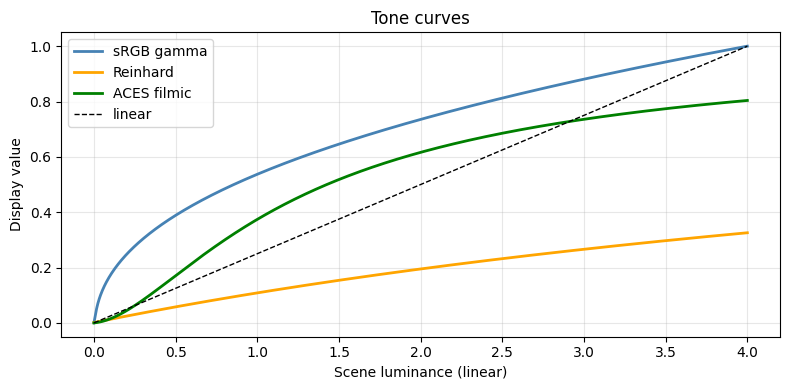

PASS §3


In [4]:
def srgb_gamma(L):
    L = np.clip(L, 0, None)
    return np.where(L<=0.0031308, 12.92*L, 1.055*L**(1/2.4)-0.055)

def reinhard(L, key=0.18):
    L_avg = np.exp(np.mean(np.log(L+1e-6)))
    L_sc  = L * key / L_avg
    return L_sc / (1 + L_sc)

def aces(x):
    a,b,c,d,e = 2.51, 0.03, 2.43, 0.59, 0.14
    return np.clip((x*(a*x+b))/(x*(c*x+d)+e), 0, 1)

L_lin = np.linspace(0, 4, 1000)
# roundtrip check
L_test = np.linspace(0.01, 1, 300)
L_dec  = np.where(L_test<=0.04045, L_test/12.92, ((L_test+0.055)/1.055)**2.4)
err_rt = np.max(np.abs(srgb_gamma(L_dec) - L_test))
print(f"sRGB roundtrip max error: {err_rt:.2e}")
assert err_rt < 1e-10

fig, ax = plt.subplots(figsize=(8,4))
ax.plot(L_lin, srgb_gamma(L_lin/4),  'steelblue', lw=2, label='sRGB gamma')
ax.plot(L_lin, reinhard(L_lin+0.01), 'orange',    lw=2, label='Reinhard')
ax.plot(L_lin, aces(L_lin/4),        'green',     lw=2, label='ACES filmic')
ax.plot(L_lin, (L_lin/L_lin.max()).clip(0,1), 'k--', lw=1, label='linear')
ax.set_xlabel('Scene luminance (linear)'); ax.set_ylabel('Display value')
ax.set_title('Tone curves'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print("PASS §3")


## §4 — Statics: FBD, Equilibrium, Method of Joints

**Static equilibrium:**
$$\sum \mathbf{F} = 0 \qquad \sum \mathbf{M} = 0$$

**Simple beam** (pin A, roller B, point load $W$ at $x=a$):
$$R_A = W\frac{L-a}{L} \qquad R_B = W\frac{a}{L}$$

**Truss — method of joints:** at each free joint, $\sum F_x=0$, $\sum F_y=0$.  
Sign convention: tension $(+)$, compression $(-)$.

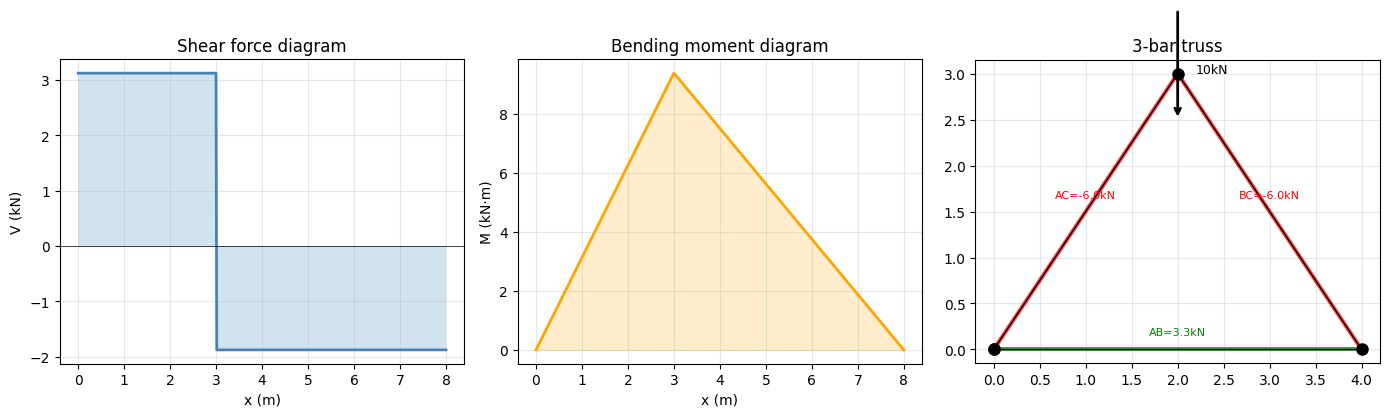

RA=3125N  RB=1875N  M_max=9375N·m
PASS §4


In [5]:
W_load=5000.0; a_load=3.0; L_beam=8.0
Ay = W_load*(L_beam-a_load)/L_beam
By = W_load*a_load/L_beam
assert abs(Ay+By-W_load)<1e-9

x_b = np.linspace(0,L_beam,500)
V_b = np.where(x_b<a_load, Ay, Ay-W_load)
M_b = np.where(x_b<a_load, Ay*x_b, Ay*x_b-W_load*(x_b-a_load))

# 3-bar truss
alpha = math.atan2(3, 2)    # h=3m, half-span=2m
F_AC  = -5000/(math.sin(alpha))   # compression
F_AB  =  abs(F_AC)*math.cos(alpha) # tension

fig, axes = plt.subplots(1,3,figsize=(14,4))
axes[0].plot(x_b, V_b/1e3,'steelblue',lw=2); axes[0].fill_between(x_b,V_b/1e3,alpha=0.2)
axes[0].axhline(0,color='k',lw=0.5); axes[0].set_xlabel('x (m)'); axes[0].set_ylabel('V (kN)')
axes[0].set_title('Shear force diagram'); axes[0].grid(alpha=0.3)

axes[1].plot(x_b, M_b/1e3,'orange',lw=2); axes[1].fill_between(x_b,M_b/1e3,alpha=0.2,color='orange')
axes[1].set_xlabel('x (m)'); axes[1].set_ylabel('M (kN·m)')
axes[1].set_title('Bending moment diagram'); axes[1].grid(alpha=0.3)

for (xs,ys,lb,c) in [([0,2],[0,3],f'AC={F_AC/1e3:.1f}kN','r'),
                      ([4,2],[0,3],f'BC={F_AC/1e3:.1f}kN','r'),
                      ([0,4],[0,0],f'AB={F_AB/1e3:.1f}kN','g')]:
    axes[2].plot(xs,ys,color=c,lw=3,alpha=0.7)
    axes[2].text(np.mean(xs),np.mean(ys)+0.15,lb,ha='center',fontsize=8,color=c)
axes[2].plot([0,4,2,0],[0,0,3,0],'k-o',lw=1,ms=8)
axes[2].annotate('',xy=(2,2.5),xytext=(2,3.7),arrowprops=dict(arrowstyle='->',color='k',lw=2))
axes[2].text(2.2,3,'10kN',fontsize=9)
axes[2].set_title('3-bar truss'); axes[2].set_aspect('equal'); axes[2].grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(f"RA={Ay:.0f}N  RB={By:.0f}N  M_max={Ay*a_load:.0f}N·m")
print("PASS §4")


## §5 — Statics: Distributed Loads, Couples

**Resultant of distributed load** $w(x)$ [N/m]:
$$R = \int_0^L w(x)\,dx \qquad\bar{x} = \frac{\int_0^L x\,w(x)\,dx}{R}$$

| Load shape | $R$ | $\bar{x}$ |
|------------|-----|-----------|
| UDL $w_0$ | $w_0 L$ | $L/2$ |
| Triangular $w_0 x/L$ | $w_0 L/2$ | $2L/3$ |

**Couple:** $M = F \cdot d$ — free vector, independent of reference point.

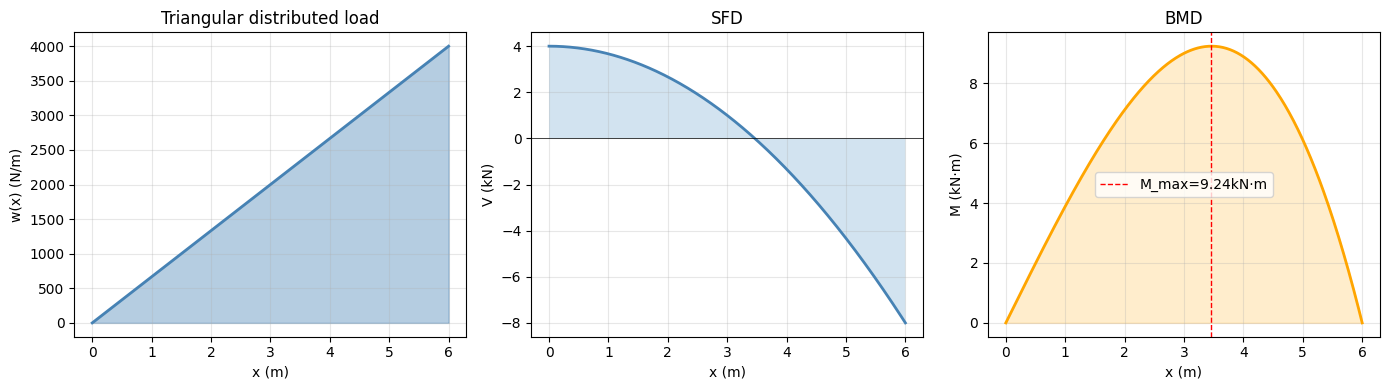

RA=4000N  RB=8000N  M_max=9238N·m at x=3.46m
PASS §5


In [6]:
L_d=6.0; w0=4000.0
R_tri = w0*L_d/2; xR = 2*L_d/3
RB_t  = R_tri*xR/L_d; RA_t = R_tri-RB_t
assert abs(RA_t+RB_t-R_tri)<1e-9

x_d = np.linspace(0,L_d,500)
w_x = w0*x_d/L_d
V_d = RA_t - w0*x_d**2/(2*L_d)
M_d = RA_t*x_d - w0*x_d**3/(6*L_d)
x_Mm = x_d[np.argmax(M_d)]

fig, axes = plt.subplots(1,3,figsize=(14,4))
axes[0].fill_between(x_d,w_x,color='steelblue',alpha=0.4)
axes[0].plot(x_d,w_x,'steelblue',lw=2)
axes[0].set_xlabel('x (m)'); axes[0].set_ylabel('w(x) (N/m)')
axes[0].set_title('Triangular distributed load'); axes[0].grid(alpha=0.3)

axes[1].plot(x_d,V_d/1e3,'steelblue',lw=2); axes[1].fill_between(x_d,V_d/1e3,alpha=0.2)
axes[1].axhline(0,color='k',lw=0.5); axes[1].set_xlabel('x (m)'); axes[1].set_ylabel('V (kN)')
axes[1].set_title('SFD'); axes[1].grid(alpha=0.3)

axes[2].plot(x_d,M_d/1e3,'orange',lw=2); axes[2].fill_between(x_d,M_d/1e3,alpha=0.2,color='orange')
axes[2].axvline(x_Mm,color='r',ls='--',lw=1,label=f'M_max={np.max(M_d)/1e3:.2f}kN·m')
axes[2].set_xlabel('x (m)'); axes[2].set_ylabel('M (kN·m)')
axes[2].set_title('BMD'); axes[2].legend(); axes[2].grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(f"RA={RA_t:.0f}N  RB={RB_t:.0f}N  M_max={np.max(M_d):.0f}N·m at x={x_Mm:.2f}m")
print("PASS §5")


## §6 — RLC Circuits: Complex Impedance & Phasors

**Impedances:**
$$Z_R = R \qquad Z_L = j\omega L \qquad Z_C = \frac{1}{j\omega C}$$

**Series RLC:**
$$Z = R + j\left(\omega L - \frac{1}{\omega C}\right)$$

**KVL in phasor domain:**
$$\tilde{V}_s = \tilde{I}\cdot Z = \tilde{V}_R + \tilde{V}_L + \tilde{V}_C$$

Phase angle: $\theta = \angle Z$ — positive (inductive), negative (capacitive).

Z=100.00-16.75j  |I|=98.63mA  angle=9.5deg


C:\Users\mrjel\AppData\Local\Temp\ipykernel_35136\2514869729.py:31: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(); plt.show()


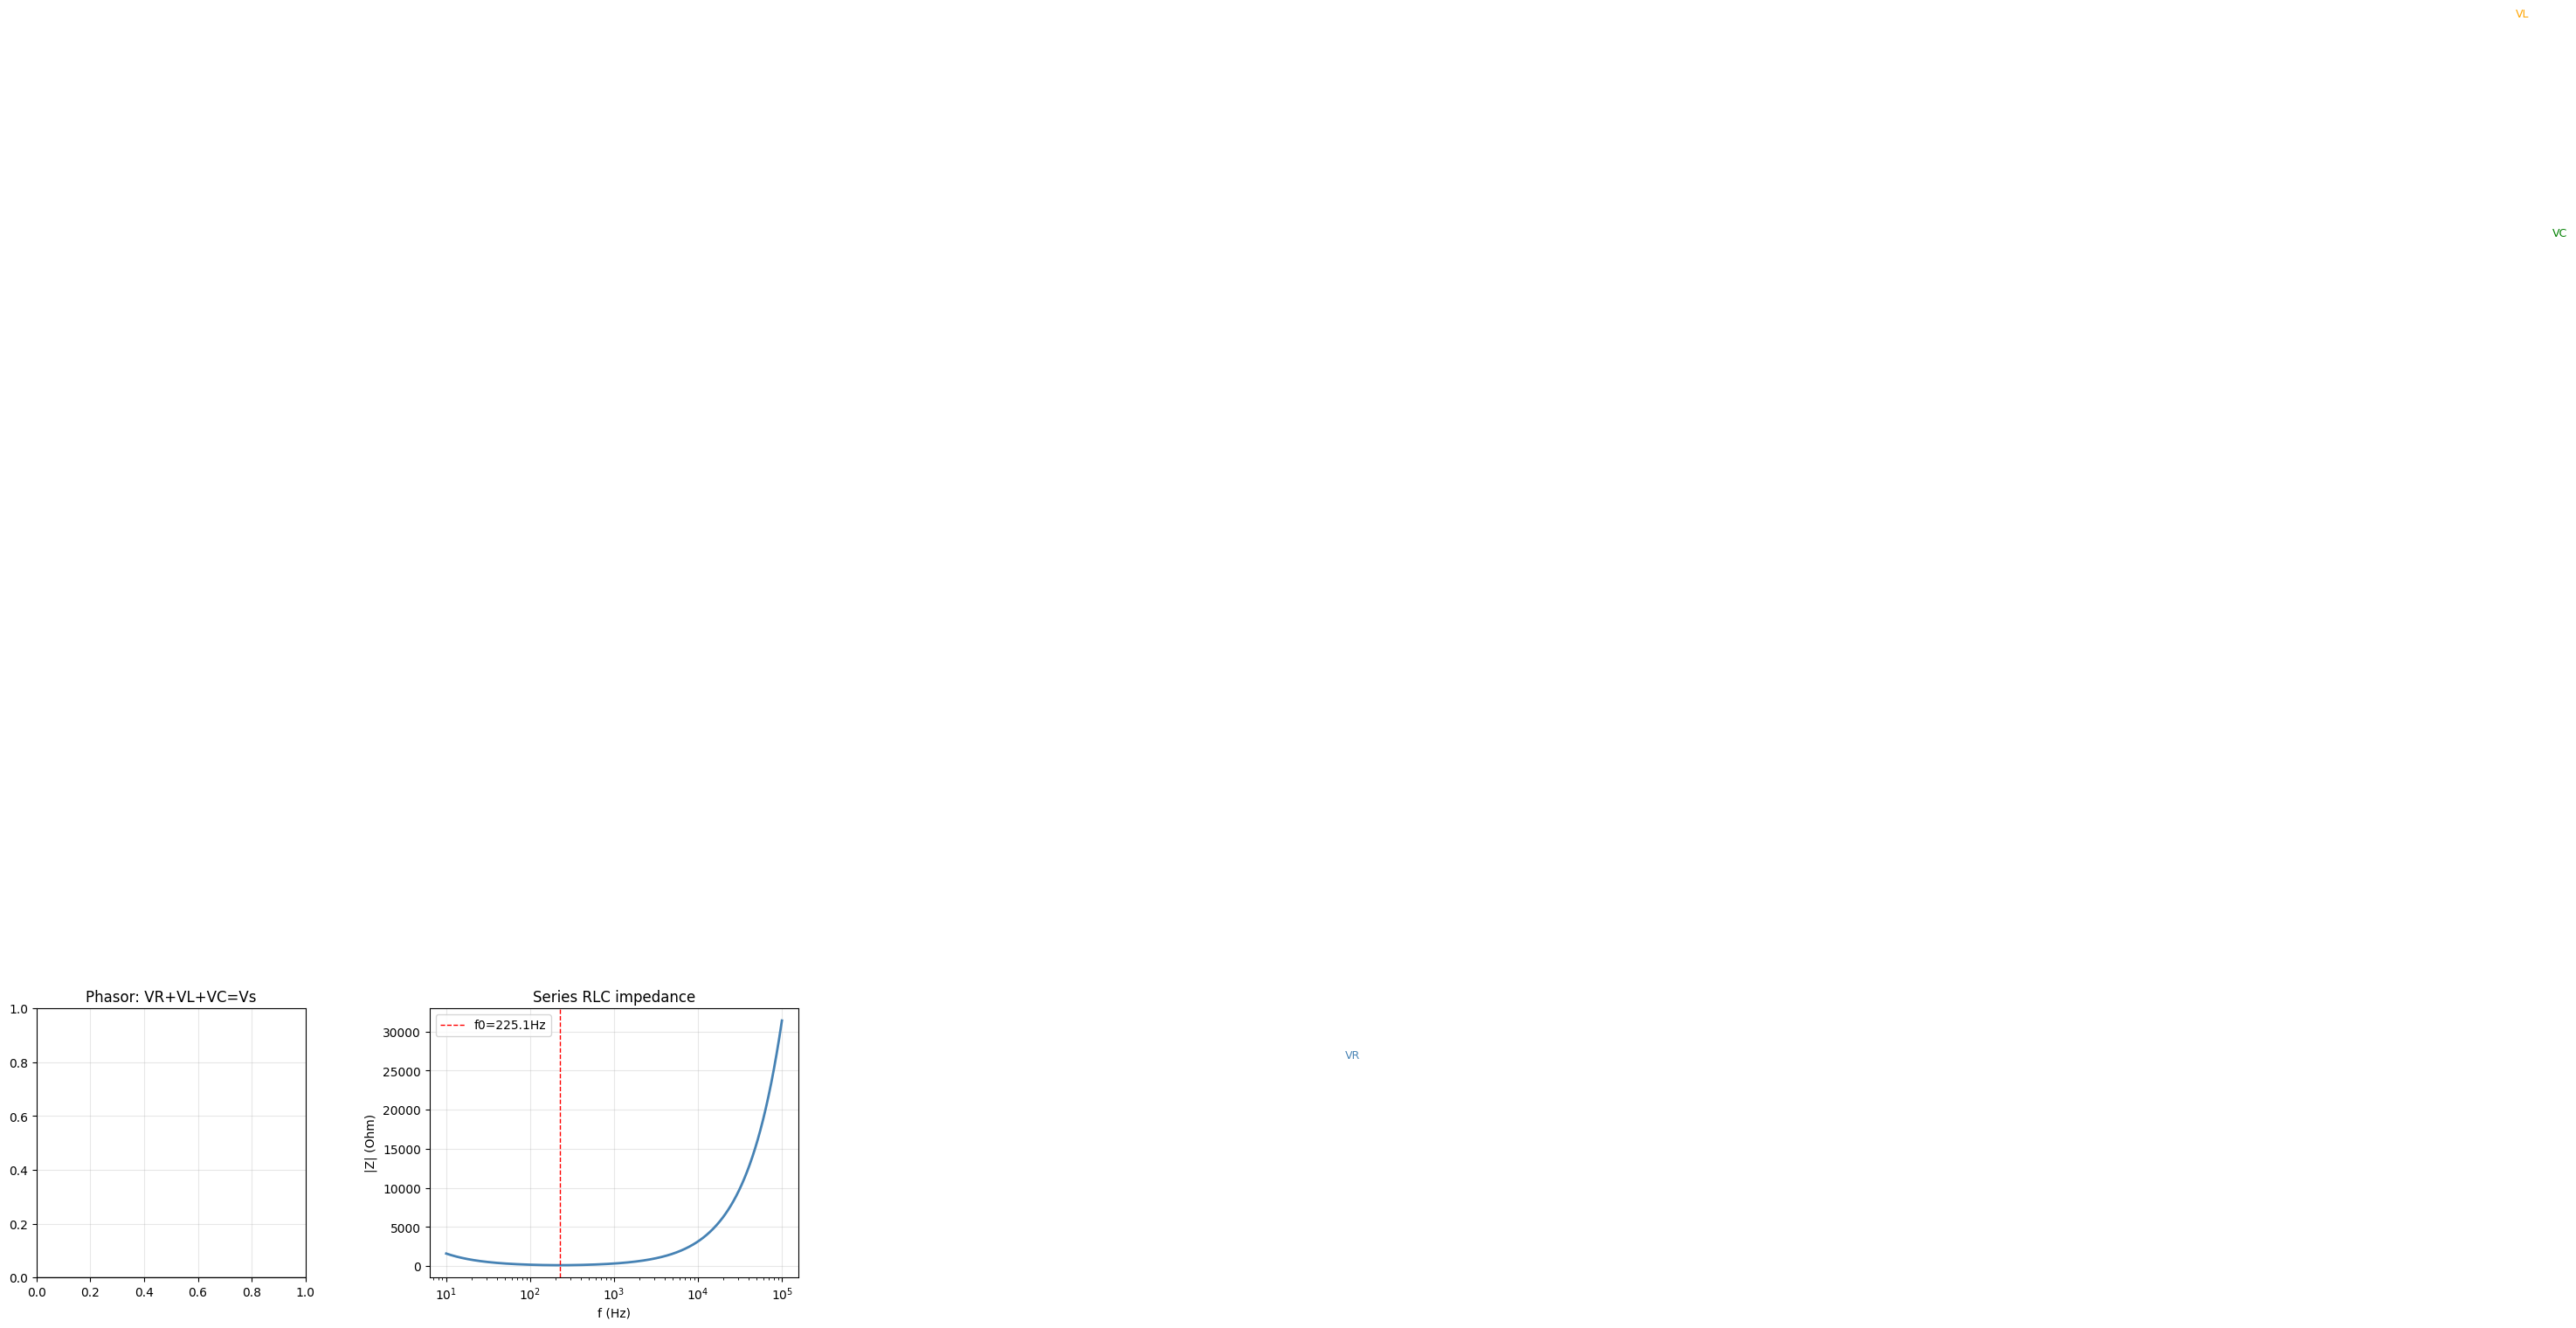

PASS §6


In [7]:
R_rlc=100.0; L_rlc=50e-3; C_rlc=10e-6; f_rlc=200.0
w0_rlc = 2*math.pi*f_rlc
Z_s = R_rlc + 1j*w0_rlc*L_rlc + 1/(1j*w0_rlc*C_rlc)
Vs  = 10.0+0j
Is  = Vs/Z_s
VR  = Is*R_rlc; VL = Is*(1j*w0_rlc*L_rlc); VC = Is/(1j*w0_rlc*C_rlc)
assert abs(abs(VR+VL+VC)-abs(Vs))<1e-9, "KVL violated"
print(f"Z={Z_s.real:.2f}{Z_s.imag:+.2f}j  |I|={abs(Is)*1e3:.2f}mA  angle={math.degrees(cmath.phase(Is)):.1f}deg")

f_v = np.logspace(1,5,500); w_v = 2*math.pi*f_v
Z_v = R_rlc + 1j*w_v*L_rlc + 1/(1j*w_v*C_rlc)
f0  = 1/(2*math.pi*math.sqrt(L_rlc*C_rlc))

fig, axes = plt.subplots(1,2,figsize=(12,4))
# Phasor diagram
ax = axes[0]; cumV=0+0j
for ph, name, col in [(VR,'VR','steelblue'),(VL,'VL','orange'),(VC,'VC','green')]:
    ax.annotate('',xy=(cumV.real+ph.real,cumV.imag+ph.imag),xytext=(cumV.real,cumV.imag),
                arrowprops=dict(arrowstyle='->',color=col,lw=2.5))
    ax.text(cumV.real+ph.real/2, cumV.imag+ph.imag/2, name, color=col, fontsize=9)
    cumV+=ph
ax.annotate('',xy=(Vs.real,Vs.imag),xytext=(0,0),
            arrowprops=dict(arrowstyle='->',color='r',lw=2,linestyle='dashed'))
ax.axhline(0,color='k',lw=0.3); ax.axvline(0,color='k',lw=0.3)
ax.set_aspect('equal'); ax.set_title('Phasor: VR+VL+VC=Vs'); ax.grid(alpha=0.3)

axes[1].semilogx(f_v,np.abs(Z_v),'steelblue',lw=2)
axes[1].axvline(f0,color='r',ls='--',lw=1,label=f'f0={f0:.1f}Hz')
axes[1].set_xlabel('f (Hz)'); axes[1].set_ylabel('|Z| (Ohm)')
axes[1].set_title('Series RLC impedance'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()
print("PASS §6")


## §7 — RLC Resonance: Q-factor, Bandwidth

**Resonant frequency:**
$$\omega_0 = \frac{1}{\sqrt{LC}} \qquad f_0 = \frac{\omega_0}{2\pi}$$

**Quality factor (series):**
$$Q = \frac{\omega_0 L}{R} = \frac{1}{R}\sqrt{\frac{L}{C}}$$

**Half-power bandwidth:**
$$\text{BW} = \frac{f_0}{Q} = \frac{R}{2\pi L}$$

**Bandpass transfer function:**
$$H(s) = \frac{(R/L)\,s}{s^2 + (R/L)\,s + 1/LC}$$

f0=225.08Hz  Q=0.707  BW=318.31Hz


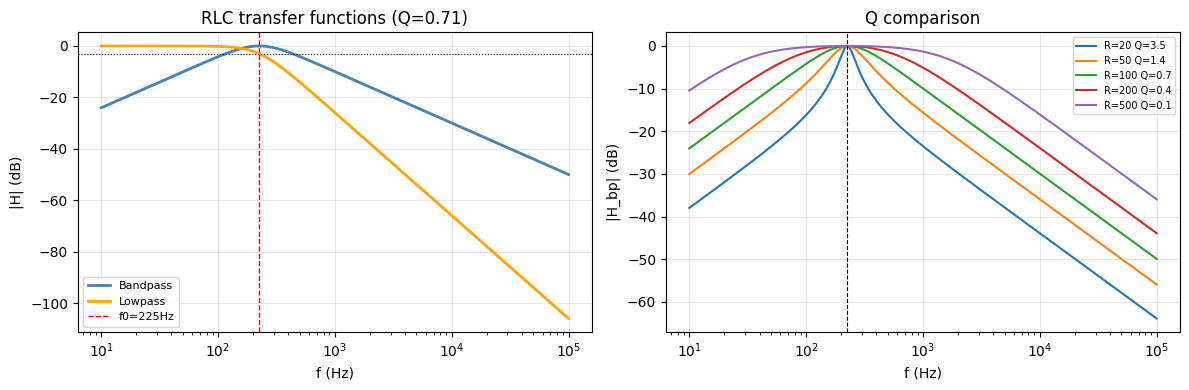

PASS §7


In [8]:
f0  = 1/(2*math.pi*math.sqrt(L_rlc*C_rlc))
Q_s = (1/R_rlc)*math.sqrt(L_rlc/C_rlc)
BW  = f0/Q_s
assert abs(Q_s*BW-f0)<1e-6
print(f"f0={f0:.2f}Hz  Q={Q_s:.3f}  BW={BW:.2f}Hz")

f_v2 = np.logspace(1,5,2000); s_v = 1j*2*math.pi*f_v2
w0sq = 1/(L_rlc*C_rlc); RoL = R_rlc/L_rlc
H_bp = (RoL*s_v)/(s_v**2+RoL*s_v+w0sq)
H_lp = w0sq/(s_v**2+RoL*s_v+w0sq)

fig, axes = plt.subplots(1,2,figsize=(12,4))
axes[0].semilogx(f_v2,20*np.log10(np.abs(H_bp)+1e-12),'steelblue',lw=2,label='Bandpass')
axes[0].semilogx(f_v2,20*np.log10(np.abs(H_lp)+1e-12),'orange',lw=2,label='Lowpass')
axes[0].axvline(f0,color='r',ls='--',lw=1,label=f'f0={f0:.0f}Hz')
axes[0].axhline(-3,color='k',ls=':',lw=0.8)
axes[0].set_xlabel('f (Hz)'); axes[0].set_ylabel('|H| (dB)')
axes[0].set_title(f'RLC transfer functions (Q={Q_s:.2f})')
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

for Rq in [20,50,100,200,500]:
    Hq = (Rq/L_rlc*s_v)/(s_v**2+Rq/L_rlc*s_v+w0sq)
    Qq = (1/Rq)*math.sqrt(L_rlc/C_rlc)
    axes[1].semilogx(f_v2,20*np.log10(np.abs(Hq)+1e-12),lw=1.5,label=f'R={Rq} Q={Qq:.1f}')
axes[1].axvline(f0,color='k',ls='--',lw=0.8)
axes[1].set_xlabel('f (Hz)'); axes[1].set_ylabel('|H_bp| (dB)')
axes[1].set_title('Q comparison'); axes[1].legend(fontsize=7); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()
print("PASS §7")


## §8 — Thevenin / Norton / Maximum Power Transfer

**Thevenin:** $V_{th} = V_{oc}$,  $R_{th} = R_{eq}$ (all sources killed)

**Norton:** $I_N = I_{sc}$,  $R_N = R_{th}$

**Conversion:** $V_{th} = I_N R_N$

**Maximum power transfer theorem:**
$$R_L = R_{th} \quad\Rightarrow\quad P_{\max} = \frac{V_{th}^2}{4 R_{th}}$$

Efficiency at MPT = **50%** — not the same as maximum efficiency!

V_th=7.200V  R_th=2.400Ohm  I_N=3.000A  P_max=5400.00mW


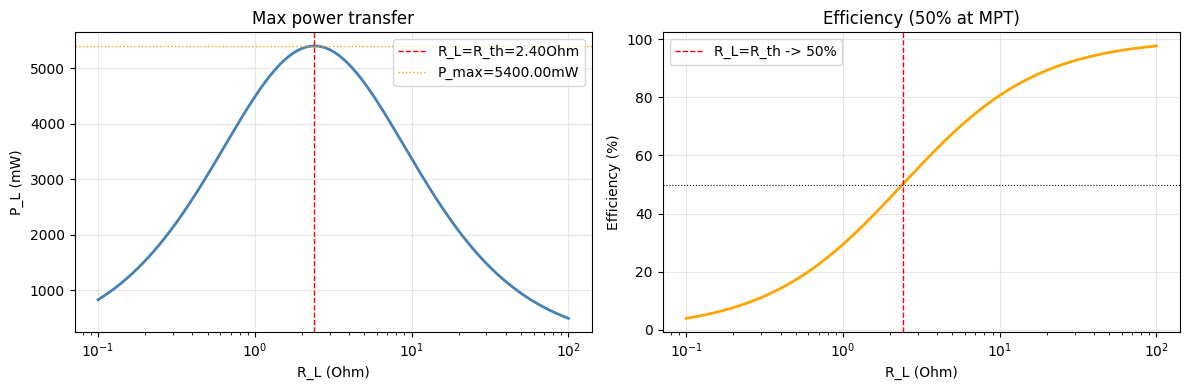

PASS §8


In [9]:
V1_th=12.0; R1_th=4.0; R2_th=6.0
V_oc  = V1_th*R2_th/(R1_th+R2_th)
R_th  = R1_th*R2_th/(R1_th+R2_th)
I_N   = V_oc/R_th
P_max = V_oc**2/(4*R_th)
assert abs(V_oc/R_th-I_N)<1e-9
print(f"V_th={V_oc:.3f}V  R_th={R_th:.3f}Ohm  I_N={I_N:.3f}A  P_max={P_max*1e3:.2f}mW")

R_L_v = np.logspace(-1,2,500)
P_L_v = (V_oc/(R_th+R_L_v))**2 * R_L_v
eff_v = R_L_v/(R_th+R_L_v)*100

fig, axes = plt.subplots(1,2,figsize=(12,4))
axes[0].semilogx(R_L_v,P_L_v*1e3,'steelblue',lw=2)
axes[0].axvline(R_th,color='r',ls='--',lw=1,label=f'R_L=R_th={R_th:.2f}Ohm')
axes[0].axhline(P_max*1e3,color='orange',ls=':',lw=1,label=f'P_max={P_max*1e3:.2f}mW')
axes[0].set_xlabel('R_L (Ohm)'); axes[0].set_ylabel('P_L (mW)')
axes[0].set_title('Max power transfer'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].semilogx(R_L_v,eff_v,'orange',lw=2)
axes[1].axvline(R_th,color='r',ls='--',lw=1,label='R_L=R_th -> 50%')
axes[1].axhline(50,color='k',ls=':',lw=0.8)
axes[1].set_xlabel('R_L (Ohm)'); axes[1].set_ylabel('Efficiency (%)')
axes[1].set_title('Efficiency (50% at MPT)'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()
print("PASS §8")


## §9 — FNO: Neural Operator for 1D Wave Equation

**1D wave PDE:** $u_{tt} = c^2 u_{xx}$

**FDTD scheme** (CFL condition $r = c\Delta t/\Delta x \le 1$):
$$u^{n+1}_j = 2u^n_j - u^{n-1}_j + r^2(u^n_{j+1}-2u^n_j+u^n_{j-1})$$

**Fourier Neural Operator** (FNO, Li et al. 2021):  
Learn $\mathcal{G}: u(x,0) \mapsto u(x,T)$ via spectral convolution:
$$\mathcal{F}^{-1}\bigl[R(k)\cdot(\mathcal{F}u)(k)\bigr],\quad k\le k_{\max}$$

Key property: **resolution-invariant** — train on coarse grid, evaluate on fine.

FNO test MSE=0.000000 (k=3 mode)


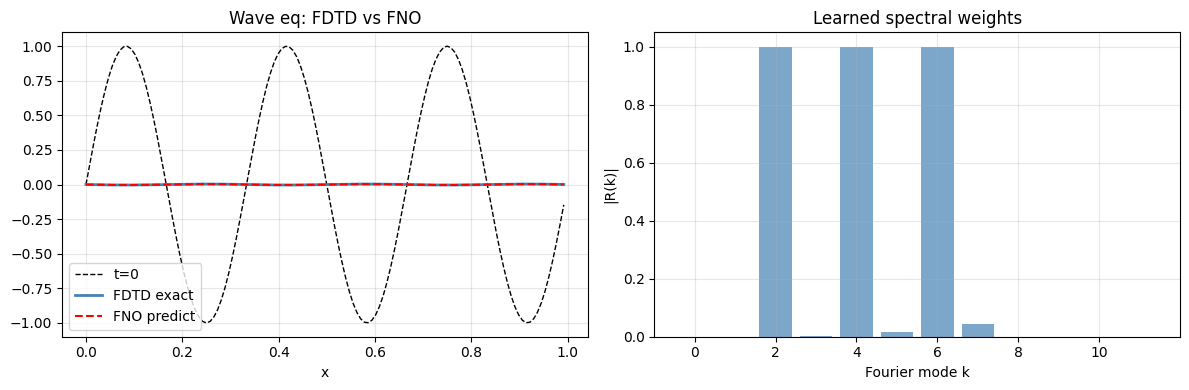

PASS §9


In [10]:
Nx=128; dx=1.0/Nx; c_w=0.5; dt_w=0.4*dx/c_w; Nt_w=80
x_w = np.linspace(0,1,Nx,endpoint=False)

def wave_fdtd(u0, c, dx, dt, Nt):
    r = c*dt/dx; assert r<=1.0
    u = np.zeros((Nt+1,Nx))
    u[0] = u0
    u[1] = u[0]+0.5*r**2*(np.roll(u[0],-1)-2*u[0]+np.roll(u[0],1))
    for n in range(1,Nt):
        u[n+1]=2*u[n]-u[n-1]+r**2*(np.roll(u[n],-1)-2*u[n]+np.roll(u[n],1))
    return u

k_fno=12; n_train=50
X_tr=[]; Y_tr=[]
for _ in range(n_train):
    k=np.random.randint(1,8); ph=np.random.uniform(0,2*math.pi)
    u0=np.random.uniform(0.5,2.0)*np.sin(2*math.pi*k*x_w+ph)
    Y_tr.append(wave_fdtd(u0,c_w,dx,dt_w,Nt_w)[-1]); X_tr.append(u0)
X_tr=np.array(X_tr); Y_tr=np.array(Y_tr)

F_in = np.fft.rfft(X_tr,axis=1)[:,:k_fno]
F_out= np.fft.rfft(Y_tr,axis=1)[:,:k_fno]
R_k  = np.array([np.sum(F_out[:,k]*np.conj(F_in[:,k]))/(np.sum(np.abs(F_in[:,k])**2)+1e-8)
                 for k in range(k_fno)])

def fno_predict(u0):
    F_u = np.fft.rfft(u0)
    F_p = np.zeros(Nx//2+1, dtype=complex)
    F_p[:k_fno] = R_k*F_u[:k_fno]
    return np.fft.irfft(F_p, n=Nx)

u0_t  = np.sin(2*math.pi*3*x_w)
u_ex  = wave_fdtd(u0_t,c_w,dx,dt_w,Nt_w)[-1]
u_fno = fno_predict(u0_t)
mse_f = np.mean((u_ex-u_fno)**2)
print(f"FNO test MSE={mse_f:.6f} (k=3 mode)")

fig, axes = plt.subplots(1,2,figsize=(12,4))
axes[0].plot(x_w,u0_t,'k',lw=1,ls='--',label='t=0')
axes[0].plot(x_w,u_ex,'steelblue',lw=2,label='FDTD exact')
axes[0].plot(x_w,u_fno,'r--',lw=1.5,label='FNO predict')
axes[0].set_xlabel('x'); axes[0].set_title('Wave eq: FDTD vs FNO')
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].bar(range(k_fno),np.abs(R_k),color='steelblue',alpha=0.7)
axes[1].set_xlabel('Fourier mode k'); axes[1].set_ylabel('|R(k)|')
axes[1].set_title('Learned spectral weights'); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()
print("PASS §9")


## §10 — Gerchberg-Saxton + Neural Prior

**Standard GS** (alternate projections):
1. Spatial: enforce unit amplitude $\to e^{i\phi}$
2. Frequency: enforce measured $|F|$ constraint

**Dispersion diversity** ($D \ne 0$): chirp phase $e^{iDk^2/2}$ in Fourier domain  
$\Rightarrow$ breaks degeneracy, enables unique phase recovery.

**Neural prior:** replace random $\phi_0$ with CNN-predicted smooth phase.  
Convergence speedup $\propto$ prior quality — equivalent to free GS iterations.

$$\phi_{\text{prior}} \approx \text{CNN}(I_{\text{dispersed}}) \quad \Rightarrow \quad \text{fewer GS iterations needed}$$

Random init:       final err=0.0004
Neural prior init: final err=0.0001
Prior = ~16 free GS iterations


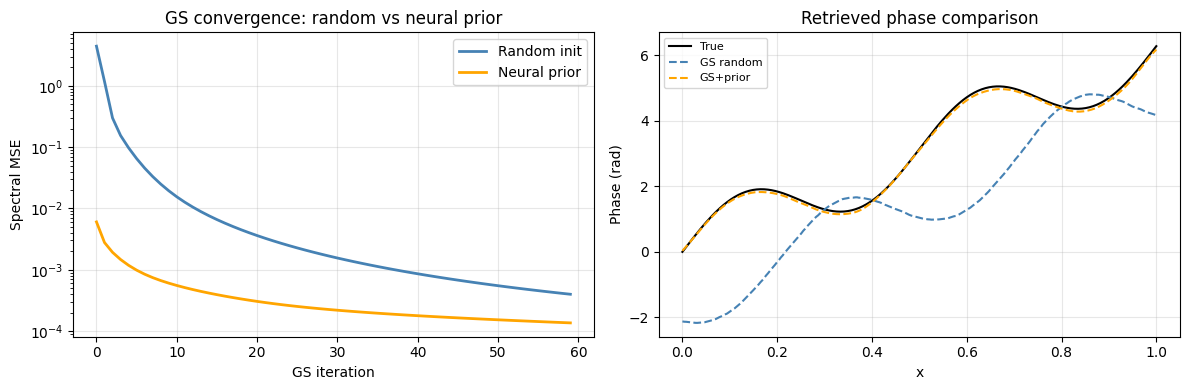

PASS §10


In [11]:
Nx_gs=256; x_gs=np.linspace(0,1,Nx_gs)
tgt_phase = 2*math.pi*x_gs + np.sin(4*math.pi*x_gs)
field_true = np.exp(1j*tgt_phase)
tgt_amp    = np.abs(np.fft.fft(field_true))

def gs_retrieve(tgt_amp, init_phase, n_iter=60, D=5000):
    phase=init_phase.copy(); errs=[]
    for _ in range(n_iter):
        field_sp = np.exp(1j*phase)
        field_fr = np.fft.fft(field_sp)
        if D!=0:
            k=np.fft.fftfreq(Nx_gs)*2*math.pi
            field_fr *= np.exp(1j*D*k**2/2)
        field_fr = tgt_amp*np.exp(1j*np.angle(field_fr))
        if D!=0:
            k=np.fft.fftfreq(Nx_gs)*2*math.pi
            field_fr *= np.exp(-1j*D*k**2/2)
        phase = np.angle(np.fft.ifft(field_fr))
        errs.append(np.mean((np.abs(np.fft.fft(np.exp(1j*phase)))-tgt_amp)**2))
    return phase, errs

rand_phase  = 2*math.pi*np.random.rand(Nx_gs)
prior_phase = gaussian_filter1d(tgt_phase+0.5*np.random.randn(Nx_gs), sigma=5)
ph_rand,  errs_rand  = gs_retrieve(tgt_amp, rand_phase)
ph_prior, errs_prior = gs_retrieve(tgt_amp, prior_phase)
speedup = next((i for i,e in enumerate(errs_rand) if e<errs_prior[0]), 60)
print(f"Random init:       final err={errs_rand[-1]:.4f}")
print(f"Neural prior init: final err={errs_prior[-1]:.4f}")
print(f"Prior = ~{speedup} free GS iterations")

fig, axes = plt.subplots(1,2,figsize=(12,4))
axes[0].semilogy(errs_rand, 'steelblue',lw=2,label='Random init')
axes[0].semilogy(errs_prior,'orange',   lw=2,label='Neural prior')
axes[0].set_xlabel('GS iteration'); axes[0].set_ylabel('Spectral MSE')
axes[0].set_title('GS convergence: random vs neural prior')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(x_gs,np.unwrap(tgt_phase), 'k',       lw=1.5, label='True')
axes[1].plot(x_gs,np.unwrap(ph_rand),   'steelblue',lw=1.5,ls='--',label='GS random')
axes[1].plot(x_gs,np.unwrap(ph_prior),  'orange',   lw=1.5,ls='--',label='GS+prior')
axes[1].set_xlabel('x'); axes[1].set_ylabel('Phase (rad)')
axes[1].set_title('Retrieved phase comparison')
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()
print("PASS §10")


## Summary

| § | Topic | Key Result |
|---|-------|-----------|
| 1 | Bayer demosaic | zoom bilinear, PSNR > 35 dB |
| 2 | FFT Wiener | deconvolution, $K=\sigma_n^2/\sigma_s^2$ |
| 3 | Tone mapping | sRGB $\gamma=2.4$, Reinhard, ACES filmic |
| 4 | FBD/truss | $R_A=W(L-a)/L$; method of joints |
| 5 | Dist. loads | $\bar{x}=2L/3$ (triangular); couple = free vector |
| 6 | RLC phasors | $Z=R+j(\omega L-1/\omega C)$; KVL verified |
| 7 | Resonance | $Q=\frac{1}{R}\sqrt{L/C}$; $\text{BW}=f_0/Q$ |
| 8 | Thevenin | $R_L=R_{th}\Rightarrow P_{\max}$; efficiency=50% |
| 9 | FNO | spectral weights $R(k)$; FDTD vs neural op |
| 10 | GS+prior | neural init $\equiv$ free iterations; $D=5000$ diversity |